# **Getting started**: two-dimensional measurements

Measured signals may get corrupted by various factors, such as measurement-induced uncertainties, physics-based resolution limitations, and noise corruption through intrinsic and external sources. The package **cssr** (compressive sensing-based super-resolver) is intended to tackle physics-based resolution limitations and noise simultaneously. Specifically, the package intends to recover signals that admit a sparse representation, which have been low-pass filtered and are subject to noise corruption. 

Analogous to one-dimensional signals, the **cssr** can be used to reconstruct two-dimensional signals as well. In this tutorial, we will see how the workflow is changed compared to one-dimensional signals following the same structure as in the previous tutorial "**Getting started:** lorentzian basis super-resolution".

## Preliminaries:

We start by importing the package **cssr**:

In [1]:
import cssr

Next, let us import the needed packages for the plotting specifications and to construct our trial signal:

In [2]:
import scipy
import numpy as np
import pylab as py
import matplotlib.pyplot as plt

Let us also specify some settings for the figures that we will construct in what will follow:

In [3]:
font1 = 17

vmin, vmax = 0.1, 0.8
levels=np.arange(vmin, vmax, 0.04)

For convenience, we disable the warnings that appear during the plotting procedure:

In [4]:
import warnings
warnings.filterwarnings("ignore", message="Casting complex values to real discards the imaginary part")

## Setting up a trial signal:

We are now ready to set up the trail signal, set up in two steps. In step 1, we construct the sparse representation of the signal, followed by applying a convolution on the sparse representation with a Lorentzian distribution (also known as a Cauchy distribution). The resulting array is called the original signal. In step 2, a lowpass filter is applied to the original signal, followed by additional signal corruption through a noise term (representing a signal as measured in a real-world scenario).

### Step 1:

#### **Sparse representation**:

We choose to set up a signal with 37 peaks, i.e., a 37-sparse signal, that represents an abstract penguin on an equidistantly spaced xy-grid:

In [24]:
x1 = np.arange(-5, 5, 0.2)
x2 = np.arange(-4, 4, 0.2)
dim1 = x1.shape[0]
dim2 = x2.shape[0]

In [25]:
abstract_penguin_idxs = np.array([
    [23, 32],[25, 34],[27, 32],[32, 23],[31, 18],[29, 13],[27,  8],[30,  4],[20,  4],
    [23,  8],[21, 13],[19, 18],[18, 23],[25, 25],[44,  9],[44, 13],[42, 17],[25, 20],
    [25, 15],[40, 21],[37, 25],[32, 28],[30, 25],[33, 20],[38, 17],[41, 13],[ 6,  9],
    [ 6, 13],[ 8, 17],[10, 21],[13, 25],[18, 28],[20, 25],[17, 20],[12, 17],[ 9, 13],
    [25, 30]
]) 

The constructed objects are used to set up the sparse trial signal $y_{\text{sparse}}$:

In [26]:
y_sparse = np.zeros((dim1, dim2))
for i, idx in enumerate(abstract_penguin_idxs[:-1]):
    y_sparse[idx[0], idx[1]] = 1
y_sparse[abstract_penguin_idxs[-1,0], abstract_penguin_idxs[-1, 1]] = 1.2

#### **Ground truth**:

To construct the original signal $y_{\text{original}}$, we choose to convolve its sparse representation with a Lorentzian distribution with half-width at half-maximum $\sigma_1 = 0.3$, and $\sigma_2 = 0.24$. This is achieved by first constructing a corresponding frame (known as a dictionary in the compressive sensing literature), which we may also refer to as the **sparsifying basis**:

In [28]:
sigma1, sigma2 = 0.3, 0.24
a0 = cssr.Frames((x1, x2)).cauchy((sigma1, sigma2))

For two-dimensional signals, the cssr package uses 4-rank tensors as sparsifying bases, in contrast to one-dimensional signals, where the sparsifying basis is a matrix. To get the ground truth signal, we use a contraction of the sparsifying basis and the sparse representation of the signal $y_{\text{sparse}}$, which represents a convolution of $y_{\text{sparse}}$ and the Cauchy distribution:

In [11]:
y_original = np.einsum('ijkl,kl->ij', a0, y_sparse)

#### Visualization:

Let us take a quick look at the constructed signal:

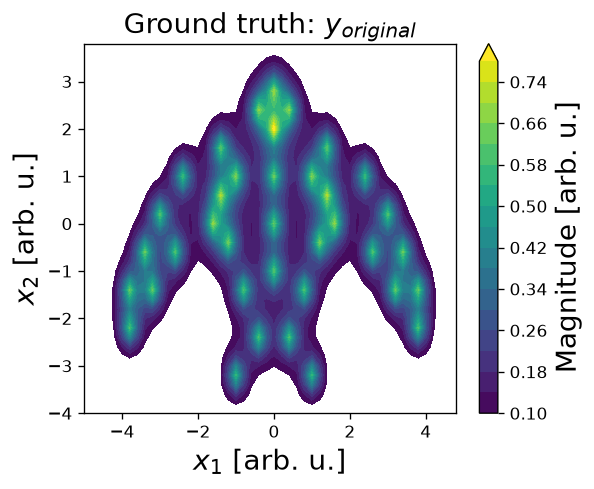

In [12]:
fig0 = plt.figure(0, figsize=(5,4), dpi=120)
plt.title("Ground truth: $y_{original}$", fontsize=font1)

plt.contourf(x1, x2, y_original.T, extend="max", levels=levels, vmin=vmin, vmax=vmax)
cbar = plt.colorbar()

cbar.set_label("Magnitude [arb. u.]", size=font1)
plt.xlabel("$x_1$ [arb. u.]", fontsize=font1)
plt.ylabel("$x_2$ [arb. u.]", fontsize=font1)
plt.show()

#### Step 2:

#### **Systemic corruption**:

We can account for system-imposed limitations on the original signal by applying a low-pass filter (giving us the signal $y_{\text{lp}}$) and adding a noise term (giving us the signal $y$). In particular, we choose an ideal low-pass filter that eliminates all frequencies beyond a critical value cutoff$_{1}=0.85$ and cutoff$_{2}=0.9$, denoted as the heaviside_lowpass_filter in the **cssr** package. Let us start with the low-pass filter. To apply the filter, we pass the original signal, its x-components, and the chosen cutoff frequency to the **Filters** class. In addition, we specify that we intend to filter a signal through the keyword argument **filter_signal**: 

In [29]:
cutoff1, cutoff2 = 0.85, 0.9
y_lp = cssr.Filters(y_original, (x1, x2), (cutoff1, cutoff2), filter_signal=True).heaviside_lowpass_filter()

Next, we add noise to the signal:

In [30]:
noise_level = np.sqrt(0.0002)
noise  = np.random.randn(len(x1), len(x2))*noise_level
y = y_lp + noise

For convenience, let quantify the signal-to-noise ration (SNR) in decibel:

In [31]:
if noise_level:
    print("SNR:", 10*np.log10(np.linalg.norm(y, "fro")/np.linalg.norm(noise, "fro")), "dB")
else:
    print("SNR:", np.inf, "dB")

SNR: 11.468069941944613 dB


#### Visualization:

Let us visualize the result:

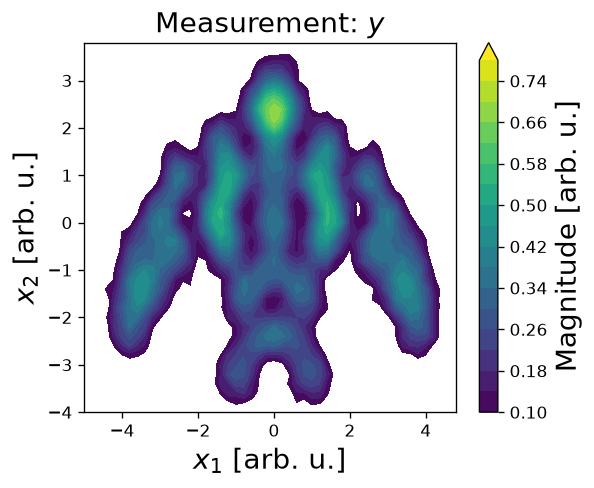

In [32]:
fig1=plt.figure(1, figsize=(5,4), dpi=120)
plt.title("Measurement: $y$", fontsize=font1)

plt.contourf(x1, x2, y.T, extend="max", levels=levels, vmin=vmin, vmax=vmax)
cbar = plt.colorbar()

cbar.set_label("Magnitude [arb. u.]", size=font1)
plt.xlabel("$x_1$ [arb. u.]", fontsize=font1)
plt.ylabel("$x_2$ [arb. u.]", fontsize=font1)
plt.show()

## Sparse basis, low-pass filters and measurement matrices:

We are now ready to set up the central objects to reconstruct signals. It is instructive to gather the needed objects (including the already constructed sparsifying matrix a0), since one would usually start a realistic reconstruction on actual data at the current point:

In [ ]:
a0 = cssr.Frames((x1, x2)).cauchy((sigma1, sigma2))

The information of the low-pass filter is encoded by applying the same operation on the sparsifying matrix through the Filters class:

In [17]:
a_tr = cssr.Filters(a0, (x1, x2), (cutoff1, cutoff2), filter_signal=False).heaviside_lowpass_filter()

The compressive sensing based approach is particularly interesting since the needed measurement matrix for the reconstruction can have considerably fewer row vectors then column vectors. Let us set the number of rows to

In [18]:
number_rows_x1, number_rows_x2 = 16, 17

Next, we can now make full use of the compressive sensing-based methodology and construct an appropriate measurement matrix. We choose a random sign "matrix"; in two dimensions, a 4-rank tensor is constructed consisting of diagonal matrices with randomly chosen values of +/- 1:

In [19]:
ar = cssr.MeasurementMatrices(a_tr, (number_rows_x1, number_rows_x2)).random_sgn_matrix()

(Note: matrices with binary entries can in principle directly be implemented into physical measurement schemes.)

## **Super-resolution**:

We are finally ready to perform the compressive sensing-based super-resolution. It is instructive to reconstruct the low-pass filtered signals with and without noise:

### Reconstructing $y_\text{original}$ from $y_\text{lp}$:

To reconstruct the noiseless signal we apply one of the algorithms implemented in the **cssr** package that solve our convex problem. In particular, we choose a hybrid algorithm called MPL assisted non-local hard thresholding, which uses the **matching pursuit** and **basis pursuit denoising** for the reconstruction. The corresponding function is called nlht_lasso, and the reconstruction is performed as follows (caution, this might take a few minutes):

In [20]:
y_lp_reconstructed, y_lp_sparse_hat = cssr.Superresolvers(a0, a_tr, ar).nlht_lasso(y_lp)

The **cssr** package returns both the reconstructed signal and its reconstructed sparse representation.

#### Visualization:

We can visualize and compare the reconstructed and the original signal as follows:

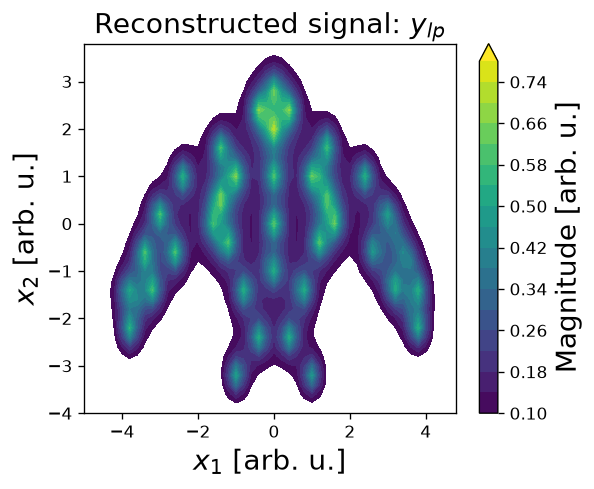

In [21]:
fig2=plt.figure(2, figsize=(5,4), dpi=120)
plt.title("Reconstructed signal: $y_{lp}$", fontsize=font1)

plt.contourf(x1, x2, y_lp_reconstructed.T, extend="max", levels=levels, vmin=vmin, vmax=vmax)
cbar = plt.colorbar()

cbar.set_label("Magnitude [arb. u.]", size=font1)
plt.xlabel("$x_1$ [arb. u.]", fontsize=font1)
plt.ylabel("$x_2$ [arb. u.]", fontsize=font1)
plt.show()

### Reconstructing $y_\text{original}$ from $y$:

The addition of noise in the corrupted signal, adds another layer of difficulty. In particular, the algorithm may not be able to resolve all sparse features once the noise level significantly overshadows the contained information. To account for the noise magnitude in the signal, we need to specify an optional argument in the solver $\lambda$:

In [22]:
if noise_level:
    noise_magnitude = np.linalg.norm(noise, "fro")**2
else:
    noise_magnitude = None
y_reconstructed, y_sparse_hat  = cssr.Superresolvers(a0, a_tr, ar).nlht_lasso(y, lam=noise_magnitude)

We have intentionally written a conditional statement for the noise magnitude determination, intended to give room for experimentation with other noise values. ( In particular, **cssr** has a default noise magnitude for lam=None for noiseless signals that mitigates instabilities. )

#### Visualization:

As before, the result can be visualized as follows:

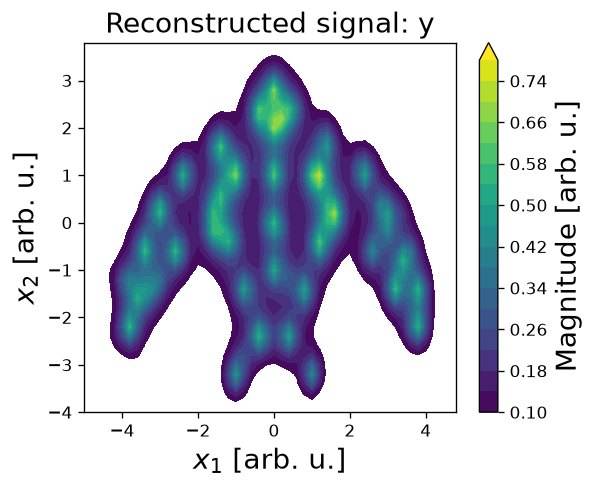

In [23]:
fig3=plt.figure(3, figsize=(5,4), dpi=120)
plt.title("Reconstructed signal: y", fontsize=font1)

plt.contourf(x1, x2, y_reconstructed.T, extend="max", levels=levels, vmin=vmin, vmax=vmax)
cbar = plt.colorbar()

cbar.set_label("Magnitude [arb. u.]", size=font1)
plt.xlabel("$x_1$ [arb. u.]", fontsize=font1)
plt.ylabel("$x_2$ [arb. u.]", fontsize=font1)
plt.show()

## Summary, conclusion and outlook:

We have observed two-dimensional signals can be reconstructed by applying compressive sensing-based methods. However, once the noise magnitude in our signal got comparable to or larger than the ground truth, the algorithm failed to resolve some sparse features. In the next tutorial, we will look at an example based on scanning tunneling microscopy data. Concretely, we will see how thermal and instrumental resolution limitations (+ noise) can be overcome through the use of the **cssr** package. Further, in the consecutive tutorial we will look at the interplay between different frames, the critical frequency (beyond which the signal has been set to zero), and measurement matrices.